In [1]:
# Характеристика 

# Исследование нелинейного МНК

In [1]:
from testing import testing
import numpy as np
import matplotlib.pyplot as plt

## Иследование на количество итераций

Зависимотсть среднего критерия от числа итераций алгоритма. 

Бесшумные данные. 45 поворотов.

<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:17: SyntaxWarning: invalid escape sequence '\o'
C:\Users\tmete\AppData\Local\Temp\ipykernel_15496\106317827.py:17: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Обобщенный критерий $\overline{J}$')


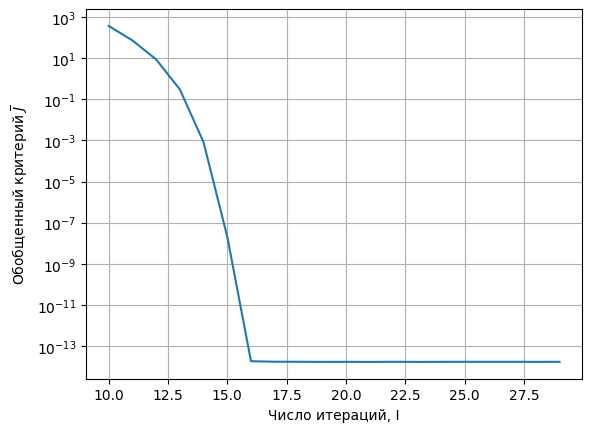

21


In [7]:
iter_num = 30
model_num = 1000

x = range(10, iter_num)
y = []

for i in x:
    res = 0
    for j in range(model_num):
        crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 1500, 0], func_params=[i, 0])
        res += crit
    res /= model_num
    y.append(res)

plt.plot(x, y)
plt.xlabel('Число итераций, I')
plt.ylabel('Обобщенный критерий $\overline{J}$')
plt.yscale('log')
plt.grid()
plt.show()

print(x[np.argmin(y)])

Зашумленные данные

In [9]:
iter_num = 30
model_num = 1000

x = range(10, iter_num)
y = []

for i in x:
    res = 0
    for j in range(model_num):
        crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 50], func_params=[i, 0])
        res += crit
    res /= model_num
    y.append(res)

plt.plot(x, y)
plt.xlabel('Число итераций, I')
plt.ylabel('Обобщенный критерий $\overline{J}$')
plt.yscale('log')
plt.grid()
plt.show()

print(x[np.argmin(y)])

<>:17: SyntaxWarning: invalid escape sequence '\o'
<>:17: SyntaxWarning: invalid escape sequence '\o'
C:\Users\tmete\AppData\Local\Temp\ipykernel_15496\2124133295.py:17: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Обобщенный критерий $\overline{J}$')
C:\Users\tmete\AppData\Local\Temp\ipykernel_15496\2124133295.py:17: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Обобщенный критерий $\overline{J}$')


KeyboardInterrupt: 

## Исследование стабильности критерия

Интервальный ряд критериев. Его статистические параметры.

Бесшумные данные. 45 поворотов. 30 итераций.

0
Выборочное мат. ожидание:  1.7308110500380282e-14
Выборочное СКО:  3.856756263105599e-15


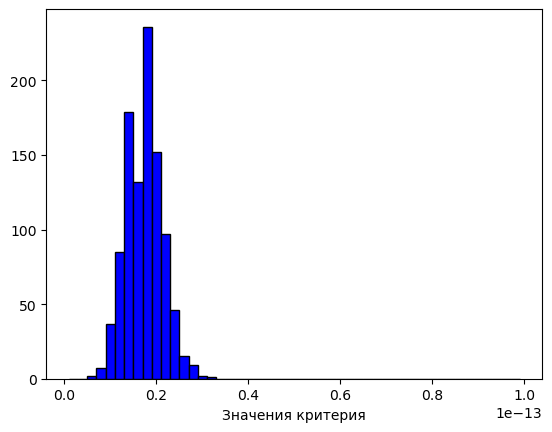

In [5]:
res = []
deads = 0
for j in range(1000):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 0], func_params=[20])
    if crit > 1e-13:
        deads += 1
        continue
    res.append(crit)

print(deads)

plt.hist(res, color='blue', edgecolor='black', bins=np.arange(1e-15, 1e-13, 2e-15))
# plt.xscale('log')
plt.xlabel('Значения критерия')

print('Выборочное мат. ожидание: ', np.mean(res))
print('Выборочное СКО: ', np.std(res))

Зашумленные данные

0
Выборочное мат. ожидание:  0.3927115120421845
Выборочное СКО:  0.06896694423988653


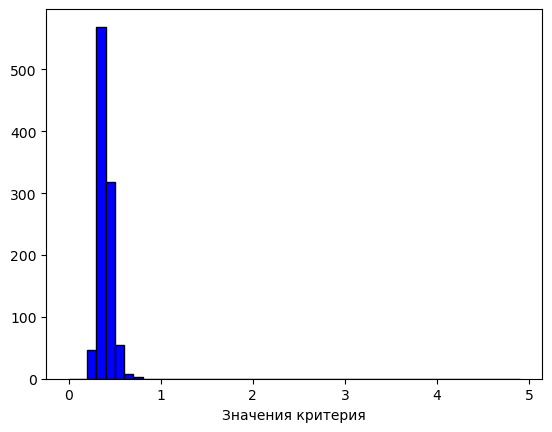

In [6]:
res = []
deads = 0
for j in range(1000):
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 50], func_params=[20])
    # if crit > 1e-13:
    #     deads += 1
    #     continue
    res.append(crit)

print(deads)

plt.hist(res, color='blue', edgecolor='black', bins=np.arange(0, 5, 0.1))
# plt.xscale('log')
plt.xlabel('Значения критерия')

print('Выборочное мат. ожидание: ', np.mean(res))
print('Выборочное СКО: ', np.std(res))

## Исследование относительной ошибки коэффициентов

Безшумные данные

0 0.0
Абс. ошибка Mx, среднее = 9.62
Абс. ошибка My, среднее = 9.07
Абс. ошибка Mz, среднее = 8.90
Абс. ошибка W0x, среднее = 0.00
Абс. ошибка W0y, среднее = 0.00
Абс. ошибка W0z, среднее = 0.00
Абс. ошибка Phi_xy [рад], среднее = 0.05
Абс. ошибка Phi_xz [рад], среднее = 0.05
Абс. ошибка Phi_yx [рад], среднее = 0.05
Абс. ошибка Phi_yz [рад], среднее = 0.05
Абс. ошибка Phi_zx [рад], среднее = 0.05
Абс. ошибка Phi_zy [рад], среднее = 0.05


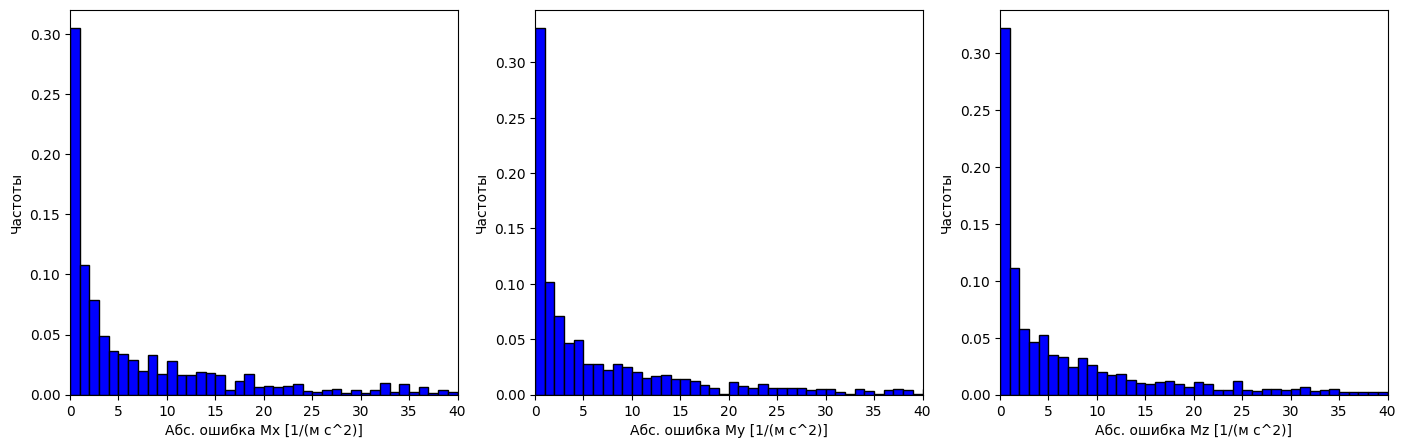

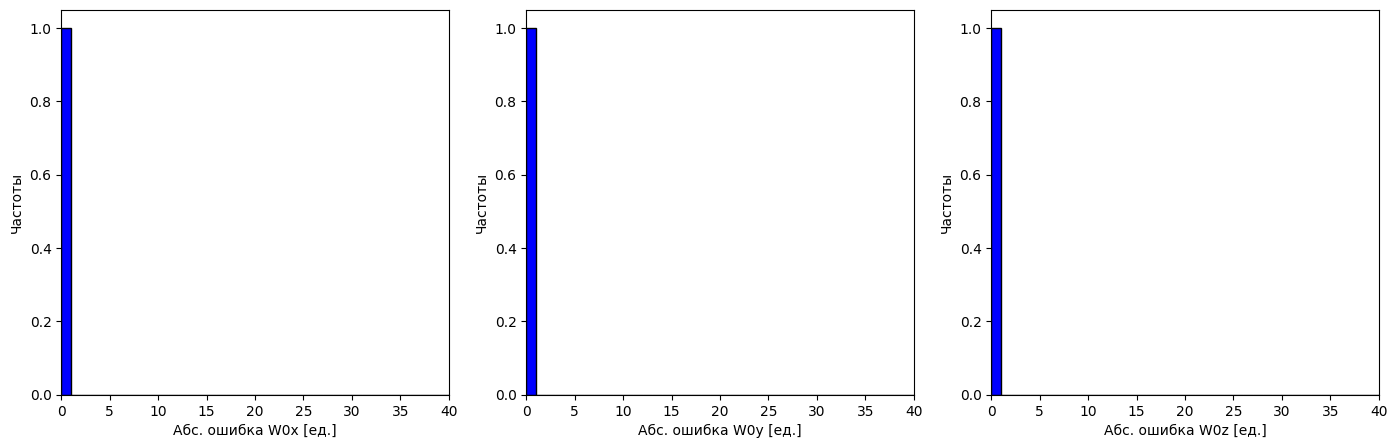

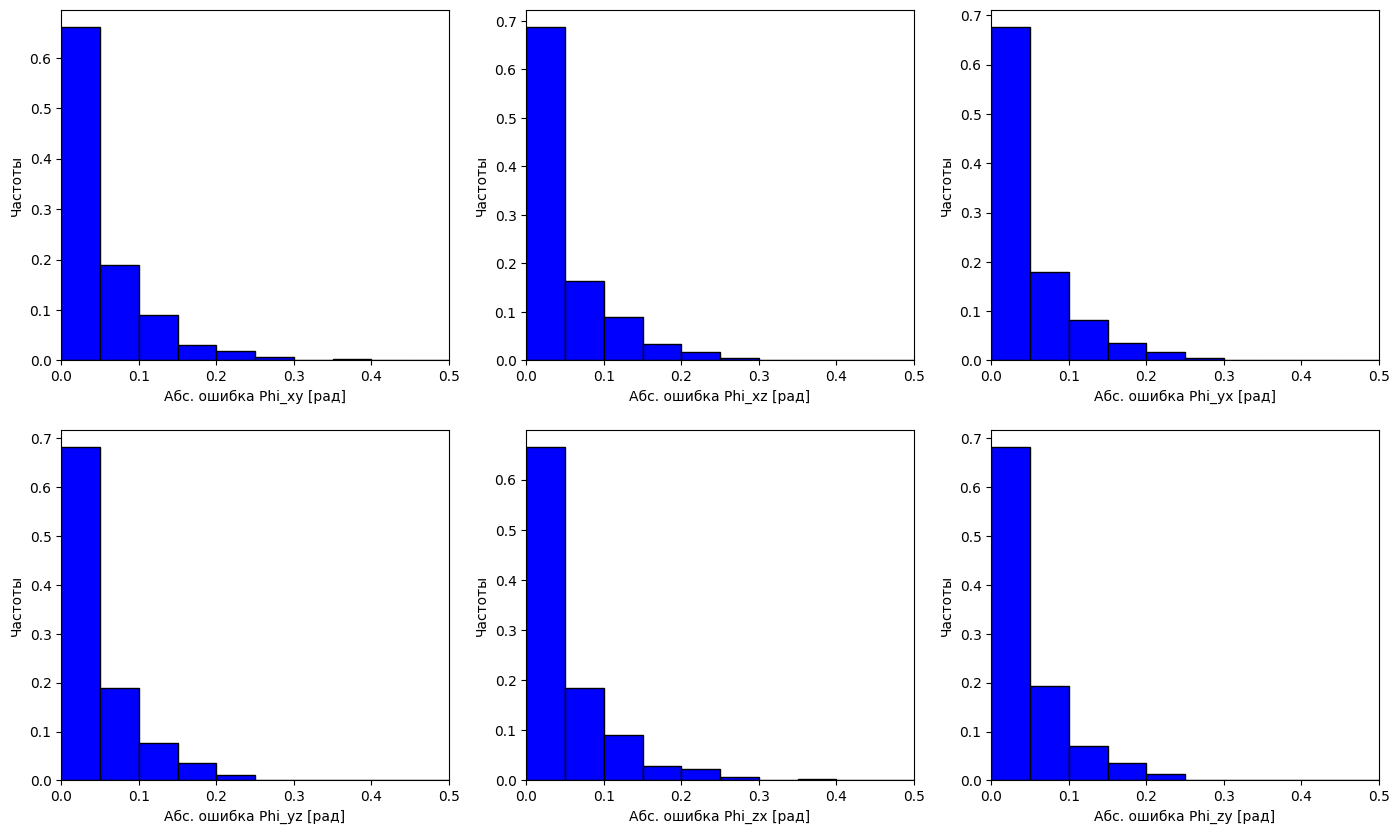

In [ ]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': [],
    'Phi_xy': [],
    'Phi_xz': [],
    'Phi_yx': [],
    'Phi_yz': [],
    'Phi_zx': [],
    'Phi_zy': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z', 'Phi_xy', 'Phi_xz', 'Phi_yx', 'Phi_yz', 'Phi_zx', 'Phi_zy']

n = 1000
deads = 0
for j in range(n):
    np.random.seed(j)
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 0], func_params=[20, 0])
    if np.max(rel[0:3] + rel[9:]) > 100:
        deads += 1
        continue
    res['Mx'].append(abse[0])
    res['My'].append(abse[1])
    res['Mz'].append(abse[2])
    res['Phi_xy'].append(abse[3])
    res['Phi_xz'].append(abse[4])
    res['Phi_yx'].append(abse[5])
    res['Phi_yz'].append(abse[6])
    res['Phi_zx'].append(abse[7])
    res['Phi_zy'].append(abse[8])
    res['W0x'].append(abse[9])
    res['W0y'].append(abse[10])
    res['W0z'].append(abse[11])

print(deads, deads / n)

plt.figure(1, figsize=(17, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 201, 1)
    plt.hist(res[axis_name[i]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 40)
    plt.xlabel(f'Абс. ошибка {axis_name[i]} [1/(м c^2)]')#, среднее = {np.mean(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')
    print(f'Абс. ошибка {axis_name[i]}, среднее = {np.mean(res[axis_name[i]]):.2f}')

plt.figure(2, figsize=(17, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 51, 1)
    plt.hist(res[axis_name[i+3]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 40)
    plt.xlabel(f'Абс. ошибка {axis_name[i+3]} [ед.]')#, среднее = {np.mean(res[axis_name[i+3]]):.2f}')
    plt.ylabel('Частоты')
    print(f'Абс. ошибка {axis_name[i+3]}, среднее = {np.mean(res[axis_name[i+3]]):.2f}')

plt.figure(3, figsize=(17, 10))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    bins = np.arange(0, 1, 0.05)
    weights = 0.001 * np.ones_like(res[axis_name[i+6]])
    plt.hist(res[axis_name[i+6]], density=False, color='blue', edgecolor='black', bins=bins, weights=weights)
    plt.xlim(0, 0.5)
    plt.xlabel(f'Абс. ошибка {axis_name[i+6]} [рад]')#, среднее = {np.mean(res[axis_name[i+6]]):.2f}')
    plt.ylabel('Частоты')
    print(f'Абс. ошибка {axis_name[i+6]} [рад], среднее = {np.mean(res[axis_name[i+6]]):.2f}')

0 0.0
Относ. ошибка Mx, среднее = 0.51
Относ. ошибка My, среднее = 0.47
Относ. ошибка Mz, среднее = 0.48
Относ. ошибка W0x, среднее = 0.00
Относ. ошибка W0y, среднее = 0.00
Относ. ошибка W0z, среднее = 0.00
Относ. ошибка Phi_xy, среднее = 72964.64
Относ. ошибка Phi_xz, среднее = 3869.50
Относ. ошибка Phi_yx, среднее = 2720.13
Относ. ошибка Phi_yz, среднее = 3145.09
Относ. ошибка Phi_zx, среднее = 2919.35
Относ. ошибка Phi_zy, среднее = 3415.55


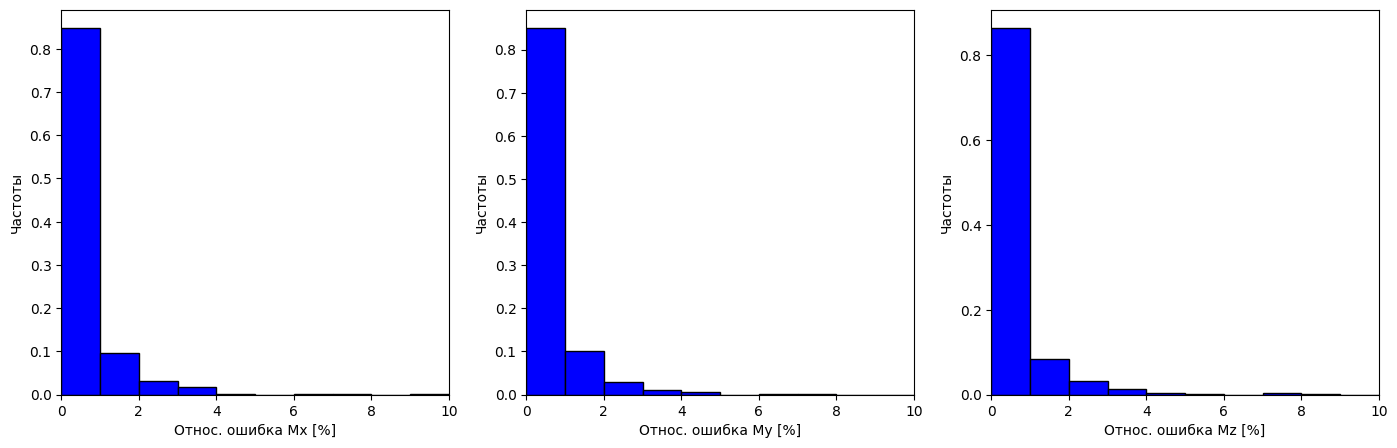

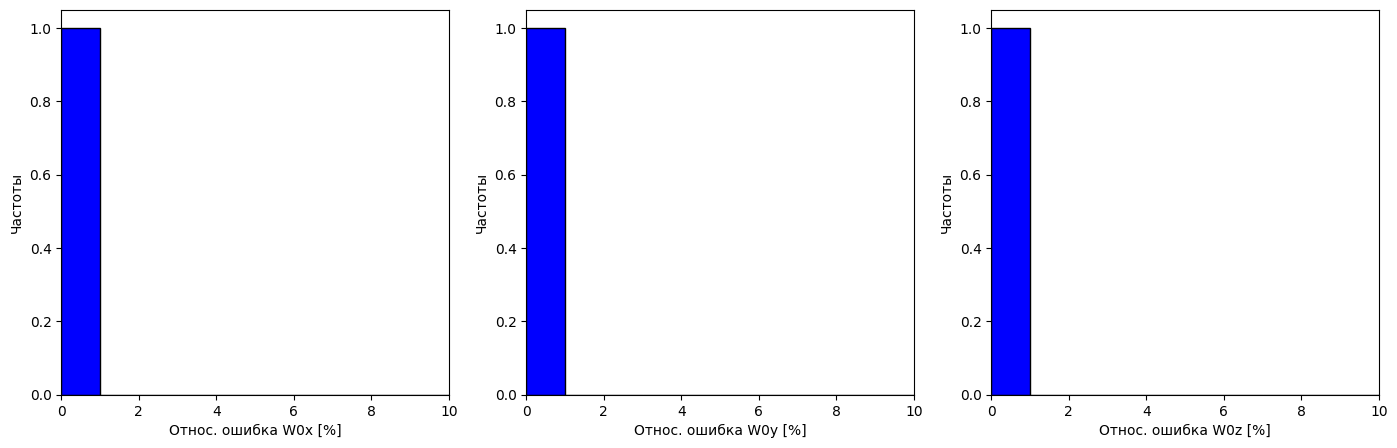

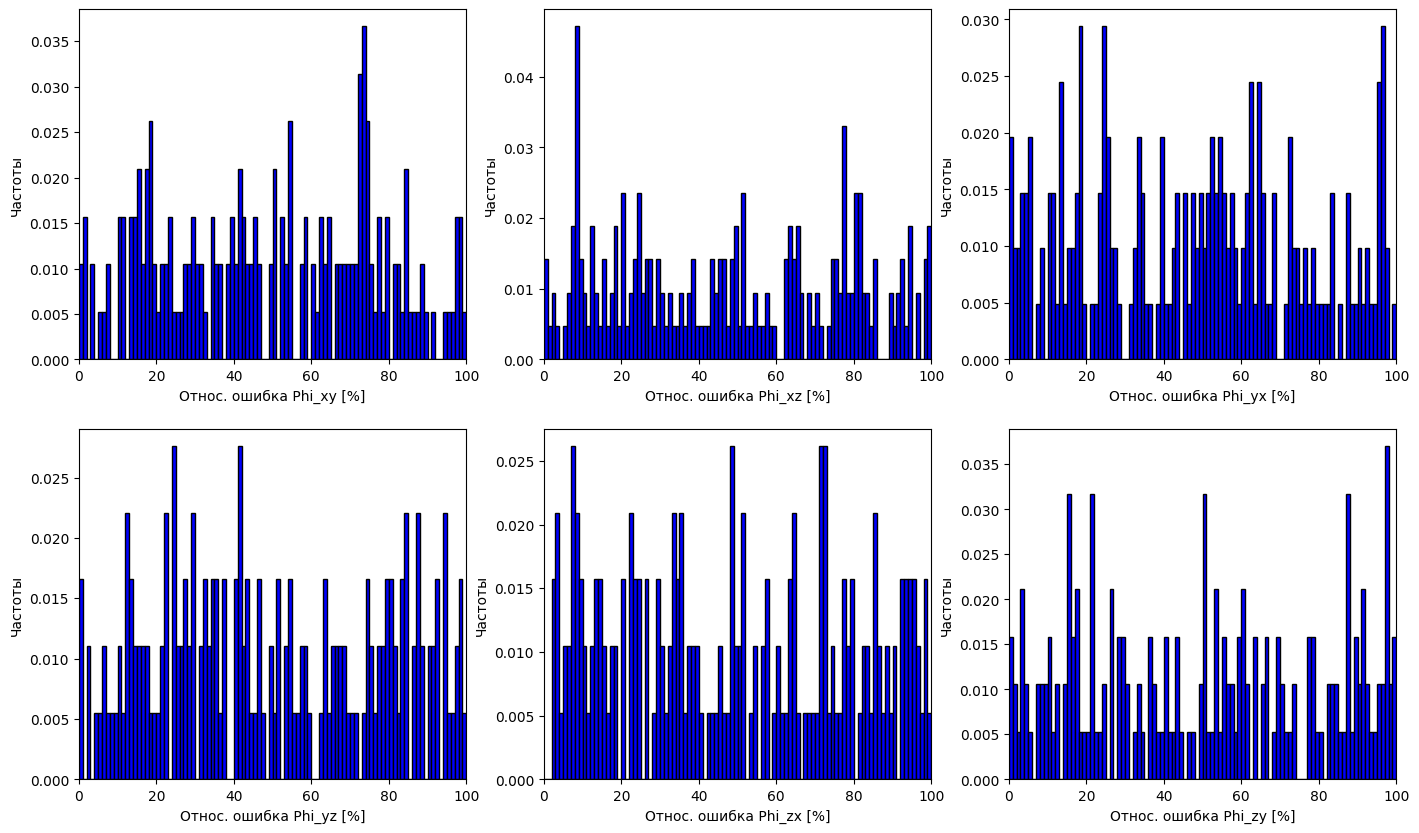

In [15]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': [],
    'Phi_xy': [],
    'Phi_xz': [],
    'Phi_yx': [],
    'Phi_yz': [],
    'Phi_zx': [],
    'Phi_zy': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z', 'Phi_xy', 'Phi_xz', 'Phi_yx', 'Phi_yz', 'Phi_zx', 'Phi_zy']

n = 1000
deads = 0
for j in range(n):
    np.random.seed(j)
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 0], func_params=[20, 0])
    if np.max(rel[0:3] + rel[9:]) > 100:
        deads += 1
        continue
    res['Mx'].append(rel[0])
    res['My'].append(rel[1])
    res['Mz'].append(rel[2])
    res['Phi_xy'].append(rel[3])
    res['Phi_xz'].append(rel[4])
    res['Phi_yx'].append(rel[5])
    res['Phi_yz'].append(rel[6])
    res['Phi_zx'].append(rel[7])
    res['Phi_zy'].append(rel[8])
    res['W0x'].append(rel[9])
    res['W0y'].append(rel[10])
    res['W0z'].append(rel[11])

print(deads, deads / n)

plt.figure(1, figsize=(17, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 10)
    plt.xlabel(f'Относ. ошибка {axis_name[i]} [%]')#, среднее = {np.mean(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')
    print(f'Относ. ошибка {axis_name[i]}, среднее = {np.mean(res[axis_name[i]]):.2f}')

plt.figure(2, figsize=(17, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+3]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 10)
    plt.xlabel(f'Относ. ошибка {axis_name[i+3]} [%]')#, среднее = {np.mean(res[axis_name[i+3]]):.2f}')
    plt.ylabel('Частоты')
    print(f'Относ. ошибка {axis_name[i+3]}, среднее = {np.mean(res[axis_name[i+3]]):.2f}')

plt.figure(3, figsize=(17, 10))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+6]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'Относ. ошибка {axis_name[i+6]} [%]')#, среднее = {np.mean(res[axis_name[i+6]]):.2f}')
    plt.ylabel('Частоты')
    print(f'Относ. ошибка {axis_name[i+6]}, среднее = {np.mean(res[axis_name[i+6]]):.2f}')



# Исследование распределения асолютных ошибок определения параметров

Зашумленные данные

22 0.022
Абс. ошибка Mx, среднее = 9.78
Абс. ошибка My, среднее = 9.39
Абс. ошибка Mz, среднее = 9.06
Абс. ошибка W0x, среднее = 7.07
Абс. ошибка W0y, среднее = 6.08
Абс. ошибка W0z, среднее = 5.55
Абс. ошибка Phi_xy [рад], среднее = 0.05
Абс. ошибка Phi_xz [рад], среднее = 0.05
Абс. ошибка Phi_yx [рад], среднее = 0.05
Абс. ошибка Phi_yz [рад], среднее = 0.05
Абс. ошибка Phi_zx [рад], среднее = 0.05
Абс. ошибка Phi_zy [рад], среднее = 0.05


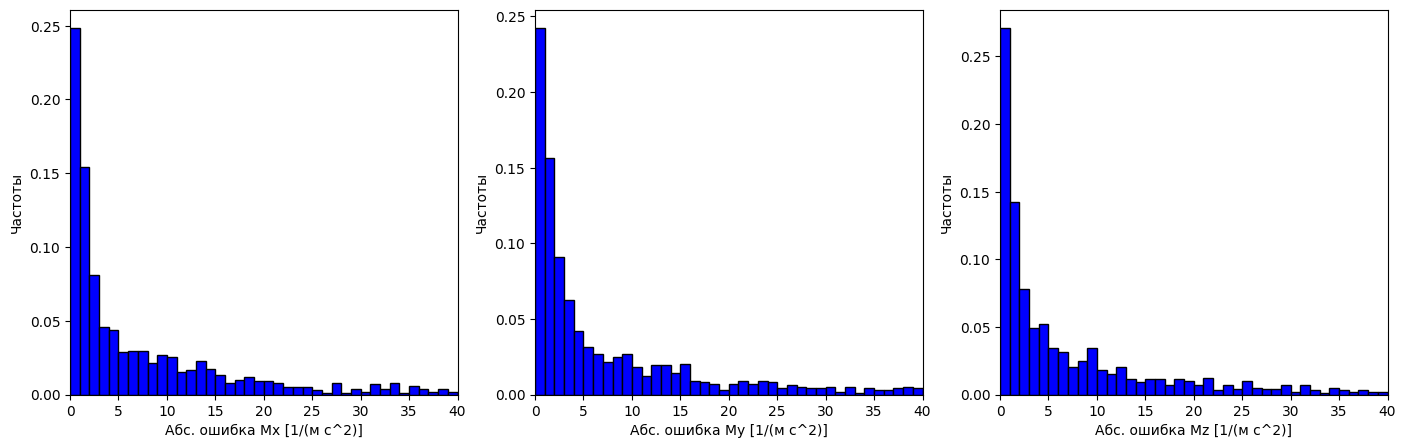

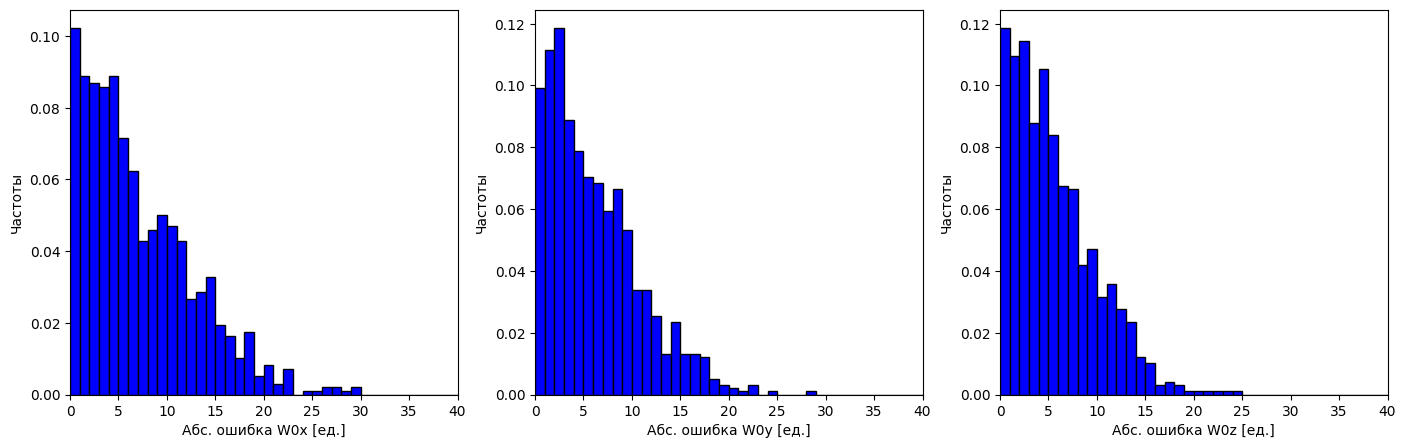

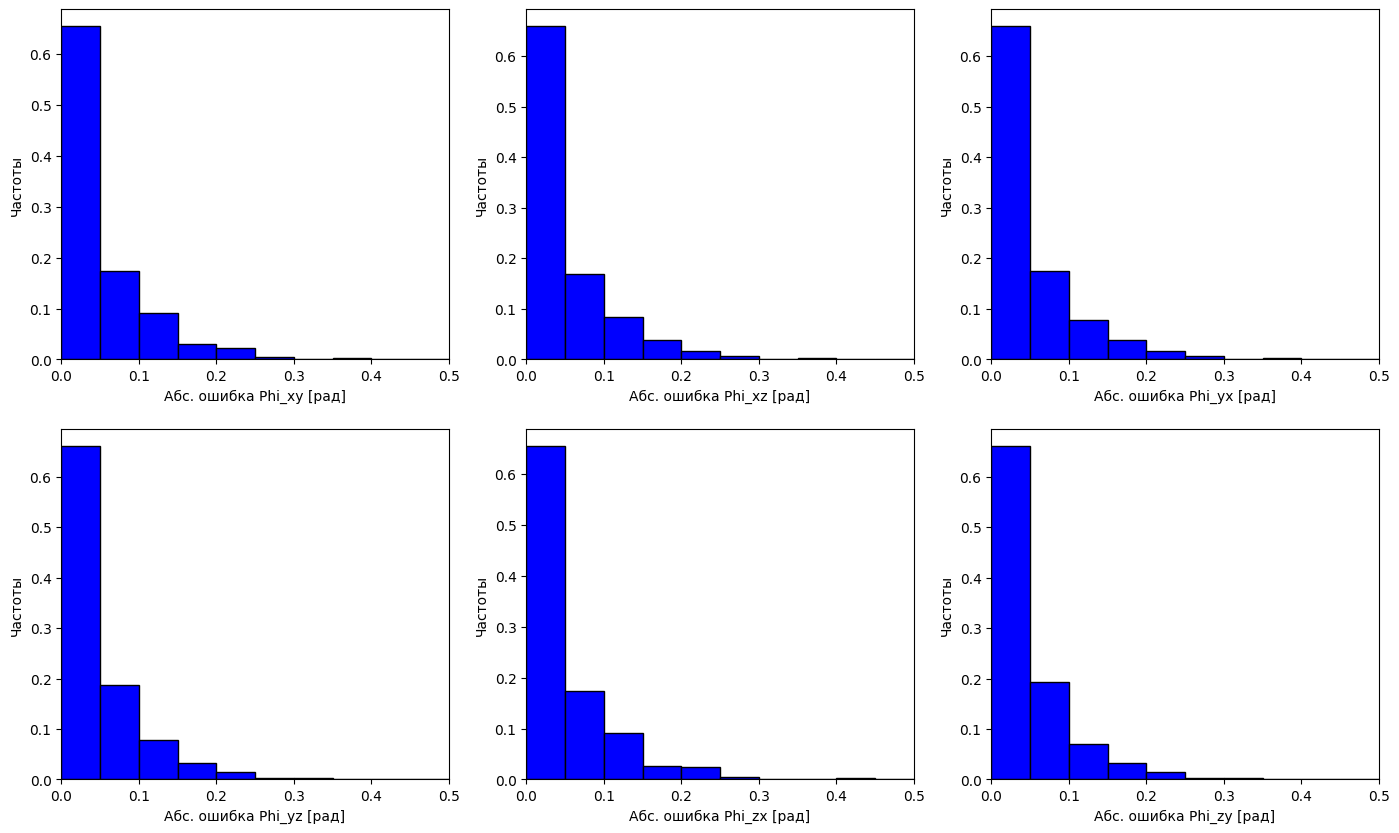

In [ ]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': [],
    'Phi_xy': [],
    'Phi_xz': [],
    'Phi_yx': [],
    'Phi_yz': [],
    'Phi_zx': [],
    'Phi_zy': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z', 'Phi_xy', 'Phi_xz', 'Phi_yx', 'Phi_yz', 'Phi_zx', 'Phi_zy']

n = 1000
deads = 0
for j in range(n):
    np.random.seed(j)
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 50], func_params=[20, 0])
    if np.max(rel[0:3] + rel[9:]) > 100:
        deads += 1
        continue
    res['Mx'].append(abse[0])
    res['My'].append(abse[1])
    res['Mz'].append(abse[2])
    res['Phi_xy'].append(abse[3])
    res['Phi_xz'].append(abse[4])
    res['Phi_yx'].append(abse[5])
    res['Phi_yz'].append(abse[6])
    res['Phi_zx'].append(abse[7])
    res['Phi_zy'].append(abse[8])
    res['W0x'].append(abse[9])
    res['W0y'].append(abse[10])
    res['W0z'].append(abse[11])

print(deads, deads / n)

plt.figure(1, figsize=(17, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 201, 1)
    plt.hist(res[axis_name[i]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 40)
    plt.xlabel(f'Абс. ошибка {axis_name[i]} [1/(м c^2)]')#, среднее = {np.mean(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')
    print(f'Абс. ошибка {axis_name[i]}, среднее = {np.mean(res[axis_name[i]]):.2f}')

plt.figure(2, figsize=(17, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 51, 1)
    plt.hist(res[axis_name[i+3]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 40)
    plt.xlabel(f'Абс. ошибка {axis_name[i+3]} [ед.]')#, среднее = {np.mean(res[axis_name[i+3]]):.2f}')
    plt.ylabel('Частоты')
    print(f'Абс. ошибка {axis_name[i+3]}, среднее = {np.mean(res[axis_name[i+3]]):.2f}')

plt.figure(3, figsize=(17, 10))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    bins = np.arange(0, 1, 0.05)
    weights = 0.001 * np.ones_like(res[axis_name[i+6]])
    plt.hist(res[axis_name[i+6]], density=False, color='blue', edgecolor='black', bins=bins, weights=weights)
    plt.xlim(0, 0.5)
    plt.xlabel(f'Абс. ошибка {axis_name[i+6]} [рад]')#, среднее = {np.mean(res[axis_name[i+6]]):.2f}')
    plt.ylabel('Частоты')
    print(f'Абс. ошибка {axis_name[i+6]} [рад], среднее = {np.mean(res[axis_name[i+6]]):.2f}')

Зашумленные данные

22 0.022
Относ. ошибка Mx, среднее = 0.52
Относ. ошибка My, среднее = 0.49
Относ. ошибка Mz, среднее = 0.49
Относ. ошибка W0x, среднее = 4.55
Относ. ошибка W0y, среднее = 4.27
Относ. ошибка W0z, среднее = 3.65
Относ. ошибка Phi_xy, среднее = 75325.30
Относ. ошибка Phi_xz, среднее = 3840.63
Относ. ошибка Phi_yx, среднее = 2782.40
Относ. ошибка Phi_yz, среднее = 3265.29
Относ. ошибка Phi_zx, среднее = 2956.02
Относ. ошибка Phi_zy, среднее = 3384.63


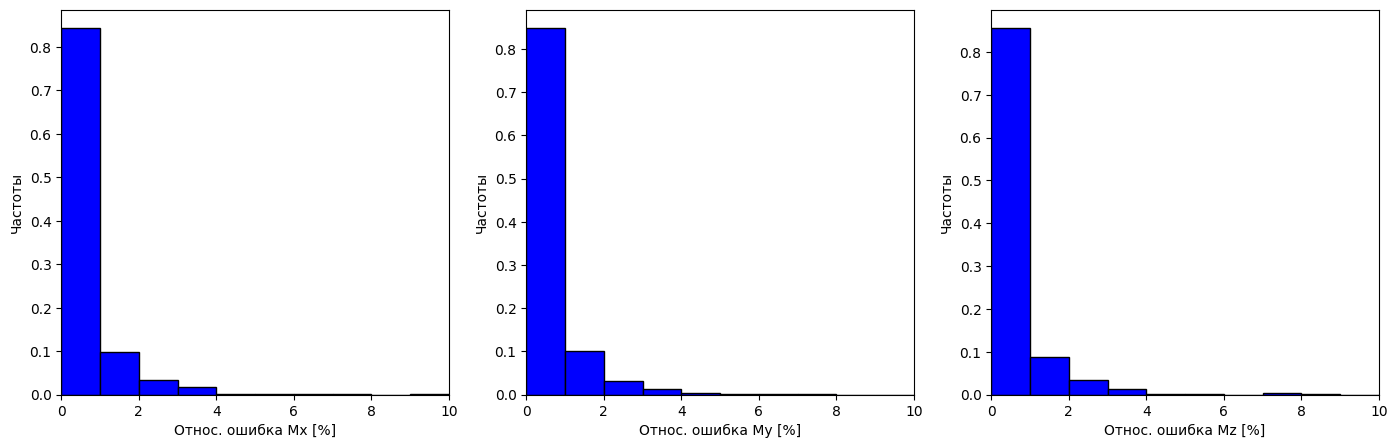

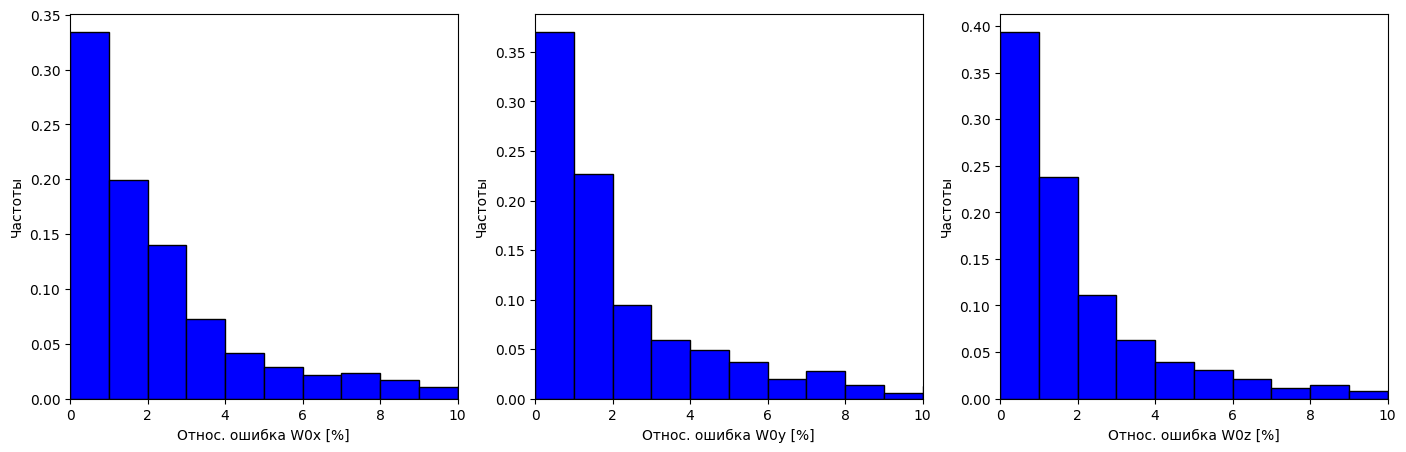

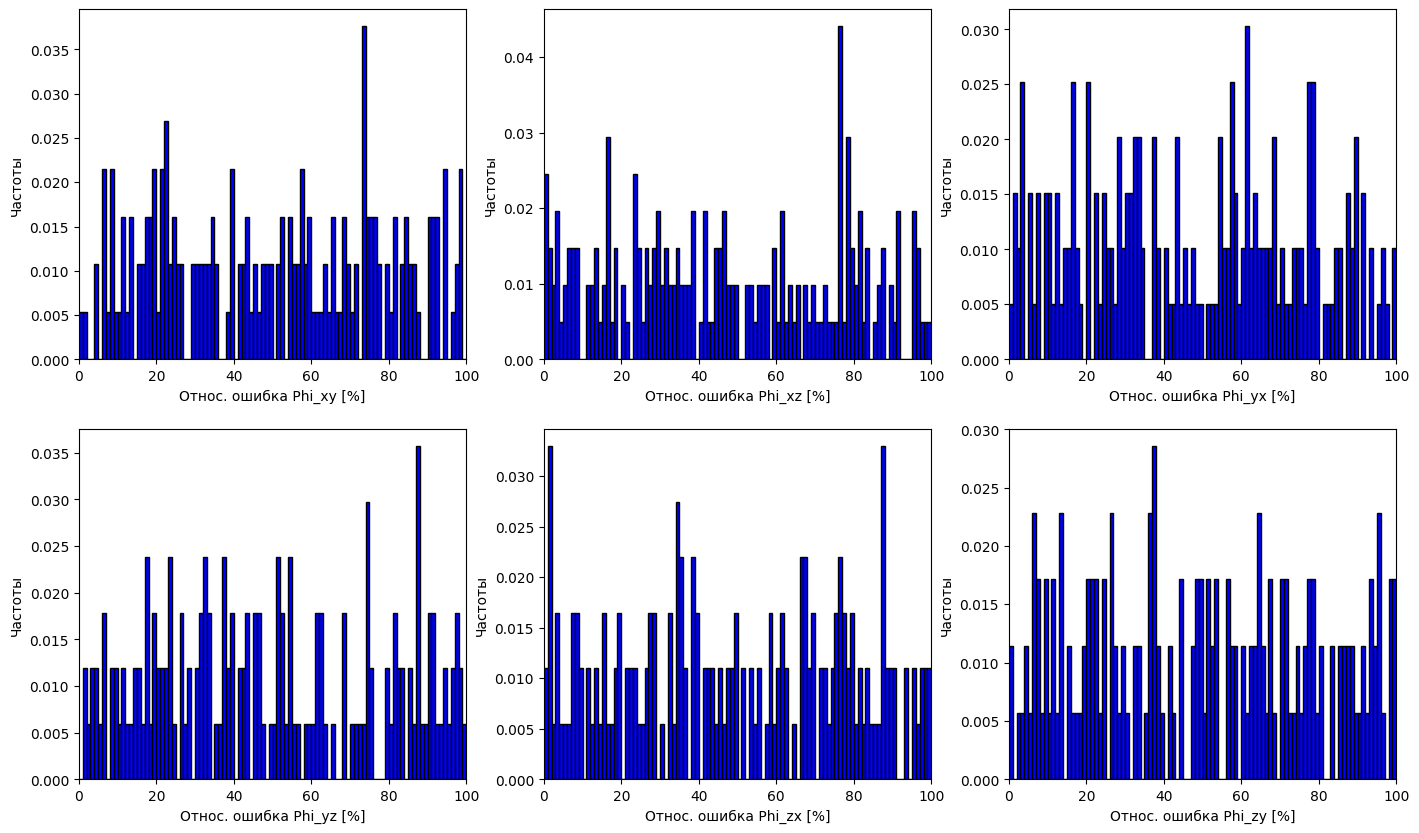

In [8]:
res = {
    'Mx': [],
    'My': [],
    'Mz': [],
    'W0x': [],
    'W0y': [],
    'W0z': [],
    'Phi_xy': [],
    'Phi_xz': [],
    'Phi_yx': [],
    'Phi_yz': [],
    'Phi_zx': [],
    'Phi_zy': []
}

axis_name = ['Mx', 'My', 'Mz', 'W0x', 'W0y', 'W0z', 'Phi_xy', 'Phi_xz', 'Phi_yx', 'Phi_yz', 'Phi_zx', 'Phi_zy']

n = 1000
deads = 0
for j in range(n):
    np.random.seed(j)
    crit, rel, abse = testing(1, 1, modeling_params=[2000, 0.01, 500, 50], func_params=[20, 0])
    if np.max(rel[0:3] + rel[9:]) > 100:
        deads += 1
        continue
    res['Mx'].append(rel[0])
    res['My'].append(rel[1])
    res['Mz'].append(rel[2])
    res['Phi_xy'].append(rel[3])
    res['Phi_xz'].append(rel[4])
    res['Phi_yx'].append(rel[5])
    res['Phi_yz'].append(rel[6])
    res['Phi_zx'].append(rel[7])
    res['Phi_zy'].append(rel[8])
    res['W0x'].append(rel[9])
    res['W0y'].append(rel[10])
    res['W0z'].append(rel[11])

print(deads, deads / n)

plt.figure(1, figsize=(17, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 10)
    plt.xlabel(f'Относ. ошибка {axis_name[i]} [%]')#, среднее = {np.mean(res[axis_name[i]]):.2f}')
    plt.ylabel('Частоты')
    print(f'Относ. ошибка {axis_name[i]}, среднее = {np.mean(res[axis_name[i]]):.2f}')

plt.figure(2, figsize=(17, 5))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+3]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 10)
    plt.xlabel(f'Относ. ошибка {axis_name[i+3]} [%]')#, среднее = {np.mean(res[axis_name[i+3]]):.2f}')
    plt.ylabel('Частоты')
    print(f'Относ. ошибка {axis_name[i+3]}, среднее = {np.mean(res[axis_name[i+3]]):.2f}')

plt.figure(3, figsize=(17, 10))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    bins = np.arange(0, 101, 1)
    plt.hist(res[axis_name[i+6]], density=True, color='blue', edgecolor='black', bins=bins)
    plt.xlim(0, 100)
    plt.xlabel(f'Относ. ошибка {axis_name[i+6]} [%]')#, среднее = {np.mean(res[axis_name[i+6]]):.2f}')
    plt.ylabel('Частоты')
    print(f'Относ. ошибка {axis_name[i+6]}, среднее = {np.mean(res[axis_name[i+6]]):.2f}')



# Изменение критерия относительно параметра

Зависимость J(M_x)

<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
C:\Users\tmete\AppData\Local\Temp\ipykernel_15496\2720561494.py:33: SyntaxWarning: invalid escape sequence '\o'
  plt.xlabel("$\overline{J}$M")


1889.506412773301


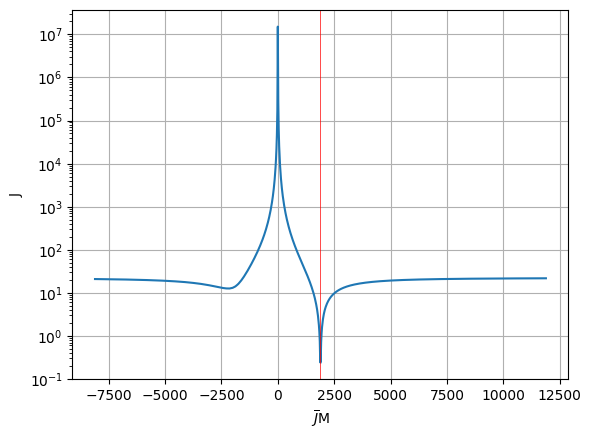

In [6]:
from utils.model import Imu
from utils.metrics import avg_criteria


m_avg = 2000
w0_sig = 500
phi_sig = 0.1
noise = 0
        
tM = np.abs(np.random.normal(m_avg, 0.2 * m_avg, size=(3, 1)))
tphi = np.random.normal(0, phi_sig, size=(6, 1))
tw0 = np.random.normal(0, w0_sig, size=(3, 1))
params = [tM[0, 0], tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                  tw0[0, 0], tw0[1, 0], tw0[2, 0]]
# print(params)
imu = Imu(params, noise)
raw_data = imu.generate_rotation(10, 20)

avg = tM[0, 0]
edge = 10000
print(avg)
y = []
x = np.linspace(avg - edge, avg + edge, 1000)
for n in x:
    params = [n, tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                  tw0[0, 0], tw0[1, 0], tw0[2, 0]]
    imu.update(params)
    y.append(avg_criteria(imu.raw_to_acc(raw_data)))

plt.plot(x, y)
plt.axvline(avg, color='red', linewidth=0.5)
plt.yscale('log')
plt.xlabel("$\overline{J}$M")
plt.ylabel('J')
plt.grid()

Зависимость J(r0)

-306.4128095808118


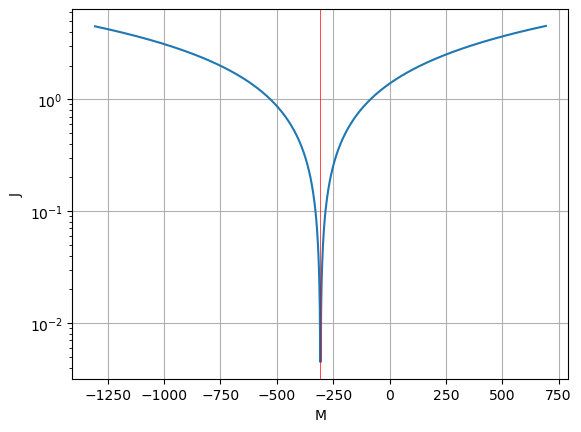

In [12]:
from utils.model import Imu
from utils.metrics import avg_criteria


m_avg = 2000
w0_sig = 500
phi_sig = 0.1
noise = 0
        
tM = np.abs(np.random.normal(m_avg, 0.2 * m_avg, size=(3, 1)))
tphi = np.random.normal(0, phi_sig, size=(6, 1))
tw0 = np.random.normal(0, w0_sig, size=(3, 1))
params = [tM[0, 0], tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                  tw0[0, 0], tw0[1, 0], tw0[2, 0]]
# print(params)
imu = Imu(params, noise)
raw_data = imu.generate_rotation(10, 20)

avg = tw0[0, 0]
edge = 1000
print(avg)
y = []
x = np.linspace(avg - edge, avg + edge, 1000)
for n in x:
    params = [tM[0, 0], tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                n, tw0[1, 0], tw0[2, 0]]
    imu.update(params)
    y.append(avg_criteria(imu.raw_to_acc(raw_data)))

plt.plot(x, y)
plt.axvline(avg, color='red', linewidth=0.5)
plt.yscale('log')
plt.xlabel("M")
plt.ylabel('J')
plt.grid()

Зависимость J(phi)

0.016734694180885478


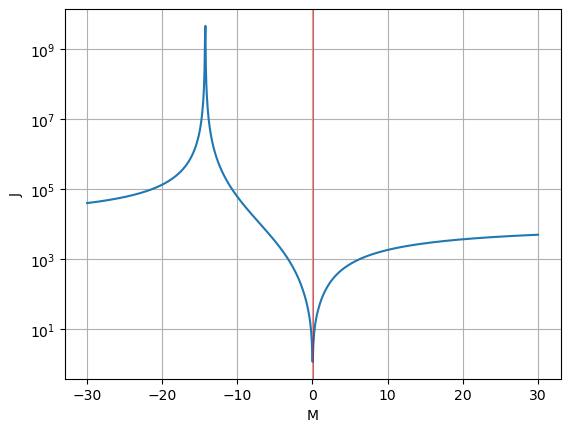

In [13]:
from utils.model import Imu
from utils.metrics import avg_criteria


m_avg = 2000
w0_sig = 500
phi_sig = 0.1
noise = 0
        
tM = np.abs(np.random.normal(m_avg, 0.2 * m_avg, size=(3, 1)))
tphi = np.random.normal(0, phi_sig, size=(6, 1))
tw0 = np.random.normal(0, w0_sig, size=(3, 1))
params = [tM[0, 0], tM[1, 0], tM[2, 0], tphi[0, 0], tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                  tw0[0, 0], tw0[1, 0], tw0[2, 0]]
# print(params)
imu = Imu(params, noise)
raw_data = imu.generate_rotation(10, 20)

avg = tphi[0, 0]
edge = 30
print(avg)
y = []
x = np.linspace(avg - edge, avg + edge, 1000)
for n in x:
    params = [tM[0, 0], tM[1, 0], tM[2, 0], n, tphi[1, 0], tphi[2, 0], tphi[3, 0], tphi[4, 0], tphi[5, 0],
                tw0[0, 0], tw0[1, 0], tw0[2, 0]]
    imu.update(params)
    y.append(avg_criteria(imu.raw_to_acc(raw_data)))

plt.plot(x, y)
plt.axvline(avg, color='red', linewidth=0.5)
plt.yscale('log')
plt.xlabel("M")
plt.ylabel('J')
plt.grid()

# Испытания на реальном датчике

Моделирование вращения при параметрах датчика:

Испытания с реальными данными

In [2]:
testing(2, 1, debug=True, func_params=[25, 100], conf_name='home_imu.conf', log_name='logs/long.log')


--- Результат калибровки ---
R_M:
[[1.46922108 0.         0.        ]
 [0.         1.72290754 0.        ]
 [0.         0.         0.68242504]]
R_r0
[[5.42676784        nan 7.06999122]
 [       nan 2.76849488        nan]
 [7.06999122        nan 9.2329683 ]]
По осям:

Ось x
M true: 1673.80958    1673.37171    0.03%    0.44
r0 true: 384.37    388.99    1.20%     4.62

Ось y
M true: 1672.71193    1664.29219    0.50%    8.42
r0 true: -72.74    -198.29    172.59%     125.55

Ось z
M true: 1686.17655    1687.71170    0.09%    1.54
r0 true: 689.26    662.85    3.83%     26.40

Phi xz: 0.01
Phi yx: 0.01
Phi xy: 0.01
Phi yz: 0.01
Phi zx: 0.00
Phi zy: 0.01
[[0.01033708]]
0.3525003606313689


c:\Users\tmete\Desktop\itmo\diploma\scalar_calibration\testing.py:94: RuntimeWarning: invalid value encountered in sqrt
  print(3 * np.sqrt(R_r0))


(0.3525003606313689,
 [np.float64(0.02616004601949505),
  np.float64(0.5033584637004637),
  np.float64(0.09104282890726031),
  np.float64(116.51390856832163),
  np.float64(52.961318171216234),
  np.float64(76.32564109519008),
  np.float64(74.95436802779523),
  np.float64(46.502508079225144),
  np.float64(149.96076133597452),
  np.float64(1.2018604345000827),
  np.float64(172.58555801266857),
  np.float64(3.830858248622879)],
 [np.float64(0.4378693569453844),
  np.float64(8.419737055895894),
  np.float64(1.535142835620718),
  np.float64(0.011651390856832162),
  np.float64(0.005296131817121624),
  np.float64(0.007632564109519008),
  np.float64(0.007495436802779523),
  np.float64(0.004650250807922514),
  np.float64(0.014996076133597453),
  np.float64(4.619566914879272),
  np.float64(125.5456383207351),
  np.float64(26.40442033012812)])

In [3]:
testing(2, 1, debug=True, func_params=[25, 100], conf_name='home_imu.conf', log_name='logs/fast.log')


--- Результат калибровки ---
R_M:
[[0.28713369 0.         0.        ]
 [0.         0.41806253 0.        ]
 [0.         0.         0.28868731]]
R_r0
[[0.93939726        nan 1.40599098]
 [       nan 0.00326721        nan]
 [1.40599098        nan 2.11047041]]
По осям:

Ось x
M true: 1673.80958    1677.70293    0.23%    3.89
r0 true: 384.37    296.85    22.77%     87.52

Ось y
M true: 1672.71193    1676.20990    0.21%    3.50
r0 true: -72.74    -1.03    98.58%     71.71

Ось z
M true: 1686.17655    1698.38315    0.72%    12.21
r0 true: 689.26    666.92    3.24%     22.33

Phi xz: 0.00
Phi yx: 0.02
Phi xy: 0.01
Phi yz: 0.01
Phi zx: 0.00
Phi zy: 0.01
[[0.01593798]]
3.427921153155127


(3.427921153155127,
 [np.float64(0.23260413068190594),
  np.float64(0.20912015768124473),
  np.float64(0.7239216310609266),
  np.float64(20.77795662597137),
  np.float64(173.93571728323113),
  np.float64(137.06155167805497),
  np.float64(148.63682923642892),
  np.float64(39.077111725257446),
  np.float64(66.20523016574613),
  np.float64(22.769386085649003),
  np.float64(98.58430217386442),
  np.float64(3.2400701713866407)],
 [np.float64(3.8933502276190666),
  np.float64(3.4979778184704173),
  np.float64(12.206596816165302),
  np.float64(0.002077795662597137),
  np.float64(0.017393571728323114),
  np.float64(0.013706155167805496),
  np.float64(0.014863682923642891),
  np.float64(0.003907711172525745),
  np.float64(0.006620523016574614),
  np.float64(87.51823390968724),
  np.float64(71.71416477335562),
  np.float64(22.332378060492715)])